<a href="https://colab.research.google.com/github/jaindevansh1001/bmi_calculator/blob/main/california_house_price_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['median_house_value'] = housing.target


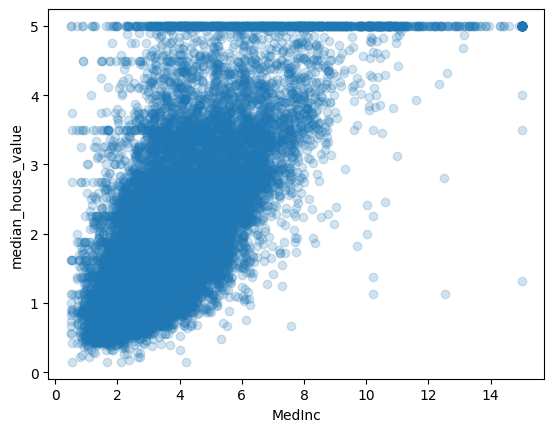

In [ ]:
linear reg on california housing eusing ANN(20) apox

In [ ]:
def set_income_category(data):
    # Use 'MedInc' instead of 'median_income' to match the column name in housing_selected
    data["income_cat"] = pd.cut(data["MedInc"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
    return data

In [ ]:
def get_strat_train_test_dataset(data):
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_index, test_index in split.split(data, data["income_cat"]):
        strat_train_set = data.loc[train_index]
        strat_test_set = data.loc[test_index]

    for set_ in (strat_train_set, strat_test_set):
        set_.drop("income_cat", axis=1, inplace=True)
    return strat_train_set, strat_test_set

In [ ]:
housing_with_income_cat = set_income_category(housing_df)
train_set, test_set = get_strat_train_test_dataset(housing_with_income_cat)


In [ ]:
housing_tr = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(housing_tr, housing_labels)

LinearRegression()

In [ ]:
housing_test = test_set.drop("median_house_value", axis=1)
housing_test_labels = test_set["median_house_value"].copy()
predictions = lin_reg.predict(housing_test)

In [ ]:
r2 = r2_score(housing_test_labels, predictions)
print(f"R-squared score: {r2}")

R-squared score: 0.61105865184937
